In [ ]:
# --timeframe 1d   : Таймфрейм свечей (дневные данные).
# --start-year 2000: Глубина загрузки истории (начиная с 2000 года).
# --workers 6      : Количество параллельных потоков для ускорения загрузки.

!python -m _tools.update_market_data --timeframe 1d --start-year 2000 --workers 18
!python -m _tools.update_macro --timeframe 1d --start-year 2000 --workers 18
# Выполняет комплексную проверку целостности, отсутствия пропусков и корректности OHLCV данных.
!python -m _tools.check_data_quality

In [ ]:
!bash start_data_swarm.sh

In [ ]:
!bash stop_data_swarm.sh

In [ ]:
!python -m _tools.check_and_heal_data

In [ ]:
#полная проверка подготовленных на предыдущем этапе данных
!python -m _tools.verify_data

In [ ]:
#Запуск нескольких процессов в параллели
!bash start_swarm.sh \
    --dataset_dir "data/processed/2000_2026_1d_18_3" \
    --bonus_ratio 0.2 \
    --min_delta 0.001 \
    --runs 500 --epochs 100 \
    --lr 2e-3 --l2_reg 1e-5 \
    --start_fold "fold_2010" \
    --factor 0.5 --patience 3 \
    --vram 10000/1 --stagger 0 \
    --keep 5 \
    --append \
    --arch attention
    #--arch cnn, conv1d+gru, mlp, attention
    #--track_trajectory
    #--init_pca_coord -148.0 -116.0 --init_pca_radius 20.0 \

In [ ]:
!./stop_swarm.sh
!python -m _tools.clean_lstm_models --keep 5

In [ ]:
!python run_all_ensembles.py --dataset_dir "data/processed/2000_2026_1d_18_3" --max_k 20

In [ ]:
%run _tools/plot_landscape.py --fold data/processed/2000_2026_1d_30_5/fold_2014

In [ ]:
%matplotlib inline
%run _tools/analyze_runs.py data/processed/2000_2026_1d_3_1/fold_2026 --runs 100 --arch attention

In [ ]:
!python -m _tools.prepare_rl_env

In [ ]:
!python -m _tools.check_env_data

In [ ]:
!python -m _tools.train_rllib_pbt --population 6 --iterations 1000 --force --cpu

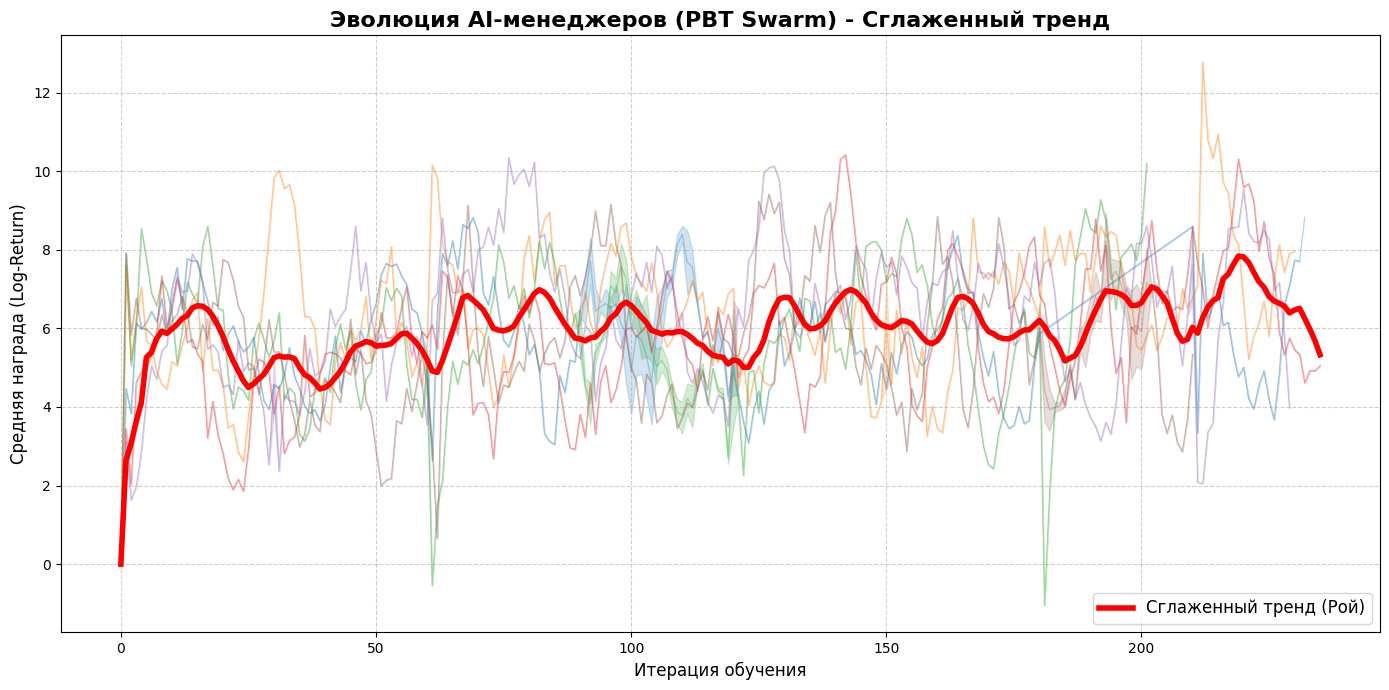

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

csv_path = "data/processed/2000_2026_1d/rl_env/training_progress.csv"

try:
    df = pd.read_csv(csv_path)
    
    plt.figure(figsize=(14, 7))
    
    # Рисуем сырые данные с сильной прозрачностью
    sns.lineplot(data=df, x='Iteration', y='Train_Return_Mean', hue='Trial_ID', alpha=0.3, linewidth=1, legend=False)
    
    # Вычисляем и рисуем сглаженный тренд всей популяции (Rolling Mean)
    df_mean = df.groupby('Iteration')['Train_Return_Mean'].mean().reset_index()
    # Сглаживаем тренд скользящим окном
    df_mean['Smoothed'] = df_mean['Train_Return_Mean'].rolling(window=5, min_periods=1).mean()
    
    plt.plot(df_mean['Iteration'], df_mean['Smoothed'], color='red', linewidth=4, label='Сглаженный тренд (Рой)')
    
    plt.title('Эволюция AI-менеджеров (PBT Swarm) - Сглаженный тренд', fontsize=16, fontweight='bold')
    plt.xlabel('Итерация обучения', fontsize=12)
    plt.ylabel('Средняя награда (Log-Return)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(loc='lower right', fontsize=12)
    plt.tight_layout()
    plt.show()
    
except Exception as e:
    print(f"⚠️ Ошибка: {e}")

2026-06-11 14:01:24,044	INFO worker.py:1828 -- Calling ray.init() again after it has already been called.


📥 Загрузка мозга агента из: checkpoint_000004 (Trial: PPO_TradingEnv-v0_43d4e_00001_1_2026-06-11_12-09-34)
🧬 [ENV] Чтение данных с диска...
🧬 [TRAIN] Сборка State Space для 63 тикеров...
🧬 [ENV] Чтение данных с диска...
🧬 [TEST] Сборка State Space для 63 тикеров...


2026-06-11 14:01:39,428	INFO trainable.py:154 -- Trainable.setup took 15.358 seconds. If your trainable is slow to initialize, consider setting reuse_actors=True to reduce actor creation overheads.
2026-06-11 14:01:39,429	WARNING util.py:62 -- Install gputil for GPU system monitoring.


🧬 [ENV] Чтение данных с диска...
🧬 [TEST] Сборка State Space для 63 тикеров...
🚀 Запуск симуляции портфельного ИИ-фонда на исторических данных...

🏁 Тест успешно завершен!
💰 Стартовый капитал: 100,000.0 руб.
📈 Финальный капитал: 223,881.28 руб.
📊 Чистый профит (OOS): 123.88%


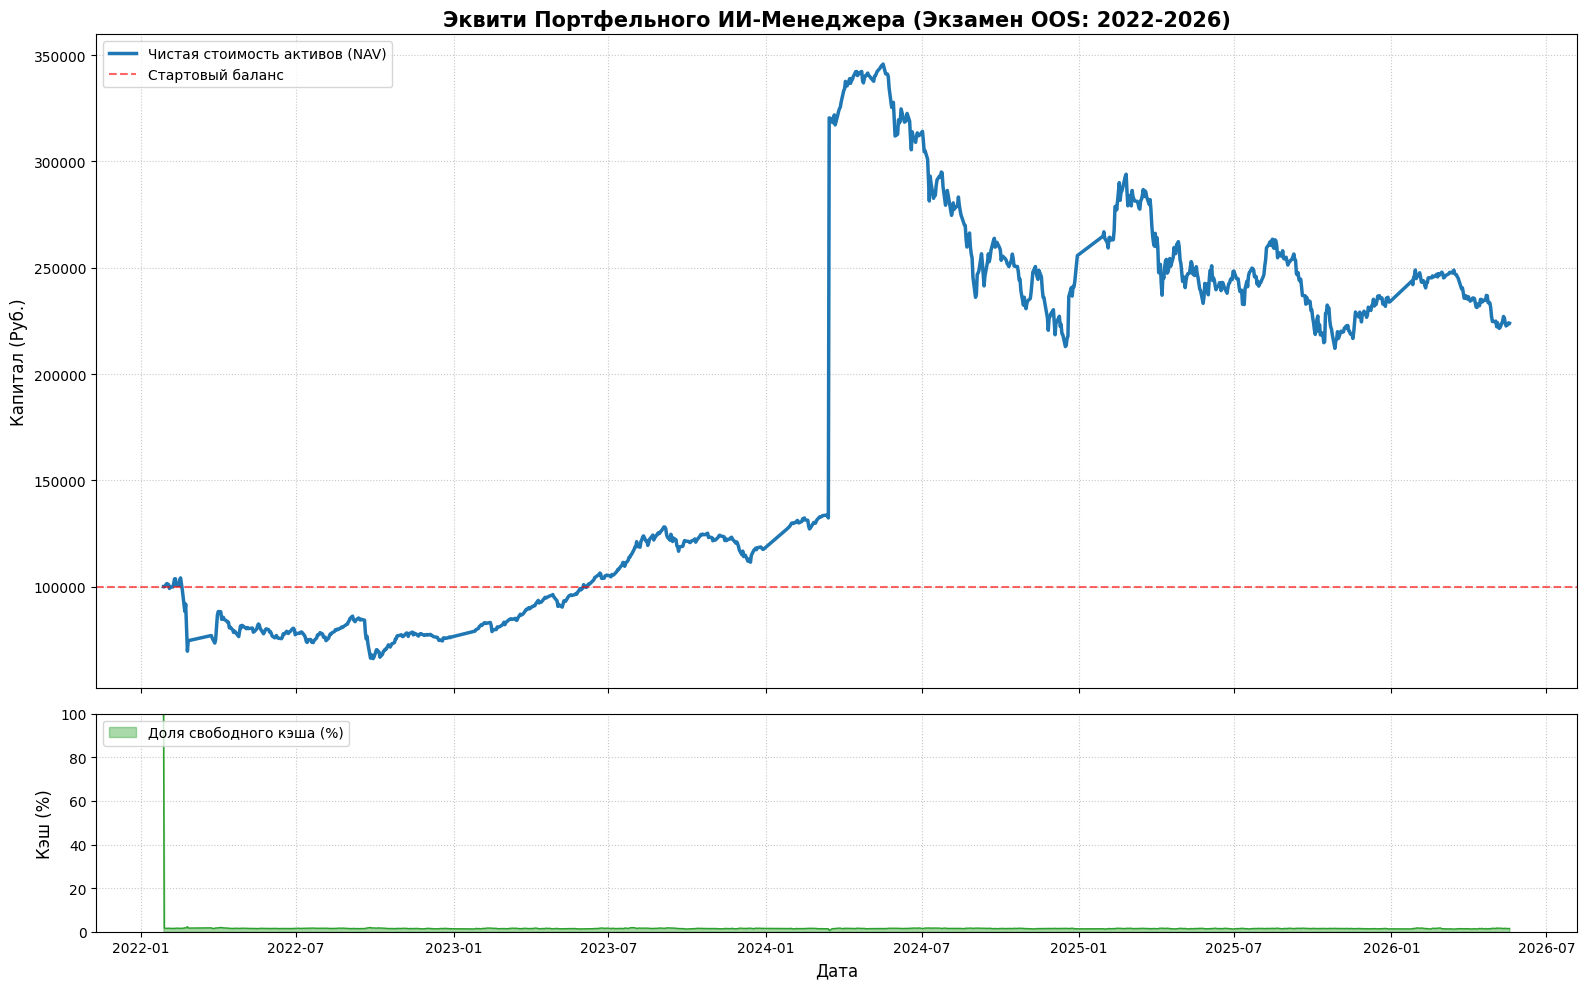

In [7]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from pathlib import Path

import ray
from ray.rllib.algorithms.algorithm import Algorithm
from ray.tune.registry import register_env

# Интегрируем нашу портфельную среду
sys.path.insert(0, os.getcwd())
from _tools.rl_env import PortfolioTradingEnv 

# Инициализируем Ray для тестов (только CPU, чтобы не мешать основному обучению)
ray.init(ignore_reinit_error=True, num_gpus=0)
register_env("TradingEnv-v0", lambda cfg: PortfolioTradingEnv(cfg))

# --- 1. АВТО-ПОИСК ЛУЧШЕГО ЧЕКПОИНТА ---
results_dir = Path(os.getcwd()) / "data/processed/2000_2026_1d/rl_env/ray_results/pbt_trading_bot"
# Ищем все папки чекпоинтов
checkpoints = [d for d in results_dir.rglob("checkpoint_*") if d.is_dir()]

if not checkpoints:
    raise ValueError("❌ Чекпоинты еще не созданы! Подождите, пока Ray сохранит хотя бы один (обычно после 10-й итерации).")

# Сортируем по времени изменения и берем самый свежий
best_checkpoint = sorted(checkpoints, key=os.path.getmtime)[-1]
print(f"📥 Загрузка мозга агента из: {best_checkpoint.name} (Trial: {best_checkpoint.parent.name})")

algo = Algorithm.from_checkpoint(str(best_checkpoint))

# --- 2. ИНИЦИАЛИЗАЦИЯ ТЕСТОВОЙ СРЕДЫ (СТРОГО OOS) ---
env_config = {
    'data_path': str(Path(os.getcwd()) / 'data/processed/2000_2026_1d/rl_env/environment_data.parquet'),
    'split_mode': 'test',  # Экзамен: 2022 - 2026!
    'commission': 0.0003, 
    'initial_balance': 100000.0, 
    'max_episode_steps': 2000 # Запас для полного прохода всей истории
}
env = PortfolioTradingEnv(env_config)

# --- 3. СИМУЛЯЦИЯ ТОРГОВ (ROLLOUT) ---
obs, info = env.reset()
done = False
truncated = False

nav_history = [env.nav]
dates = [pd.to_datetime(env.unique_dates[env.current_step])]
cash_history = [env.current_weights[-1]]

print("🚀 Запуск симуляции портфельного ИИ-фонда на исторических данных...")

while not (done or truncated):
    # Локальный инференс модели (быстрее и без блокировок)
    action, state_out, info_dict = policy.compute_single_action(obs, explore=False)
    
    obs, reward, done, truncated, info = env.step(action)
    
    nav_history.append(env.nav)
    dates.append(pd.to_datetime(info['date']))
    cash_history.append(info['cash_weight'])

print(f"\n🏁 Тест успешно завершен!")
print(f"💰 Стартовый капитал: {env_config['initial_balance']:,} руб.")
print(f"📈 Финальный капитал: {env.nav:,.2f} руб.")
profit_pct = ((env.nav / env_config['initial_balance']) - 1) * 100
print(f"📊 Чистый профит (OOS): {profit_pct:.2f}%")

# --- 4. ВИЗУАЛИЗАЦИЯ УПРАВЛЕНИЯ ПОРТФЕЛЕМ ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

# График 1: Кривая капитала фонда (Equity / NAV)
ax1.plot(dates, nav_history, color='#1f77b4', linewidth=2.5, label='Чистая стоимость активов (NAV)')
ax1.axhline(y=env_config['initial_balance'], color='red', linestyle='--', alpha=0.6, label='Стартовый баланс')
ax1.set_title('Эквити Портфельного ИИ-Менеджера (Экзамен OOS: 2022-2026)', fontsize=15, fontweight='bold')
ax1.set_ylabel('Капитал (Руб.)', fontsize=12)
ax1.grid(True, linestyle=':', alpha=0.7)
ax1.legend(loc='upper left')

# График 2: Позиционирование в Кэше (Защита от риска)
ax2.fill_between(dates, 0, np.array(cash_history) * 100, color='#2ca02c', alpha=0.4, label='Доля свободного кэша (%)')
ax2.plot(dates, np.array(cash_history) * 100, color='#2ca02c', linewidth=1)
ax2.set_ylabel('Кэш (%)', fontsize=12)
ax2.set_xlabel('Дата', fontsize=12)
ax2.set_ylim(0, 100)
ax2.grid(True, linestyle=':', alpha=0.7)
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()